# Notebook 08 — AI-Assisted Geothermal Workflow (Bonus Challenge)
**AGD 2026 | AI Workflow Engineer**

Goal: Demonstrate `GeothermalAIAssistant` — a system that ingests processed
well data and outputs a structured geothermal assessment report automatically.

This is the bonus challenge deliverable. It shows genuine AI automation:
a user passes a well name → the system returns a full structured report
with data quality rating, petrophysical interpretation, reservoir verdict,
risk register, and a DEVELOP / INVESTIGATE / REJECT recommendation.

**Requires:** `ANTHROPIC_API_KEY` environment variable set.

In [1]:
import sys, warnings, yaml, os
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
from pathlib import Path

with open("../config/settings.yaml") as f:
    CFG = yaml.safe_load(f)

PROC_DIR   = Path("..") / CFG["paths"]["data"]["processed"]
INTER_DIR  = Path("..") / CFG["paths"]["data"]["interim"]
EXTERNAL   = Path("..") / CFG["paths"]["data"]["external"]
REPORT_DIR = Path("..") / CFG["paths"]["outputs"]["reports"]
FIG_DIR    = Path("..") / CFG["paths"]["outputs"]["figures"]

from src.ai_workflow.assistant import GeothermalAIAssistant, WellAssessmentRequest

# ── API key detection ──────────────────────────────────────────────────────
gemini_key    = os.environ.get("GEMINI_API_KEY", "")
anthropic_key = os.environ.get("ANTHROPIC_API_KEY", "")
api_key       = gemini_key or anthropic_key   # kept for legacy checks

if gemini_key:
    print(f"✅ GEMINI_API_KEY found — full AI reports will be generated (free)")
elif anthropic_key:
    print(f"✅ ANTHROPIC_API_KEY found — full AI reports will be generated (paid)")
else:
    print("⚠  No API key found — running in MOCK mode (template reports)")
    print("")
    print("To get FREE full AI reports using Google Gemini:")
    print("  1. Go to https://aistudio.google.com and sign in with Google")
    print("  2. Click Get API Key → Create API Key → copy it")
    print("  3. In PowerShell BEFORE running this notebook:")
    print("       $env:GEMINI_API_KEY = \"AIza...your-key-here\"")
    print("  4. Then re-run the notebook from the top")


✅ GEMINI_API_KEY found — full AI reports will be generated (free)


## 1. Load all processed data

In [2]:
# Load the most complete processed DataFrame available
perm_path = PROC_DIR / "permeability_profiles.csv"
imp_path  = INTER_DIR / "all_wells_imputed.csv"

if perm_path.exists():
    unified = pd.read_csv(perm_path)
    print(f"Loaded permeability profiles: {unified.shape}")
elif imp_path.exists():
    unified = pd.read_csv(imp_path)
    print(f"Loaded imputed dataset: {unified.shape}")
else:
    unified = pd.read_csv(PROC_DIR / "all_wells_merged.csv")
    print(f"Loaded merged dataset: {unified.shape}")

# Feasibility scores
scores_path = REPORT_DIR / "feasibility_scores.csv"
scores = pd.read_csv(scores_path) if scores_path.exists() else pd.DataFrame()
print(f"Feasibility scores: {scores.shape}")

# ── ThermoGIS: correct wide-format parse (sheet = well, rows = properties) ──
thermo_raw = pd.read_excel(EXTERNAL / "ThermoGIS Data.xlsx", sheet_name=None)
thermo = {}
for well_name, df_t in thermo_raw.items():
    df_t.columns = [str(c).strip() for c in df_t.columns]
    header_row = df_t[df_t.iloc[:, 0].astype(str).str.strip() == "Property"].index
    if len(header_row) == 0:
        continue
    hr = header_row[0]
    data = df_t.iloc[hr+1:].copy()
    data.columns = ["Property", "Unit", "P90", "P50", "P10"]
    data = data.dropna(subset=["Property"])
    data["Property"] = data["Property"].astype(str).str.strip()
    data = data.set_index("Property")
    thermo[well_name] = {
        prop: {
            "P90": float(row["P90"]) if str(row["P90"]) not in ("nan","") else None,
            "P50": float(row["P50"]) if str(row["P50"]) not in ("nan","") else None,
            "P10": float(row["P10"]) if str(row["P10"]) not in ("nan","") else None,
        }
        for prop, row in data.iterrows()
    }

print(f"ThermoGIS wells loaded: {list(thermo.keys())}")
for well_name, props in thermo.items():
    flow = props.get("Flow Rate", {})
    temp = props.get("Temperature", {})
    print(f"  {well_name}: Flow P50={flow.get('P50')} m³/h, Temp P50={temp.get('P50')} °C")


Loaded permeability profiles: (99379, 35)
Feasibility scores: (12, 19)


ThermoGIS wells loaded: ['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']
  BLT-01: Flow P50=105.0 m³/h, Temp P50=77.0 °C
  EVD-01: Flow P50=0.0 m³/h, Temp P50=72.0 °C
  JUT-01: Flow P50=55.0 m³/h, Temp P50=72.0 °C
  PKP-01: Flow P50=0.0 m³/h, Temp P50=88.0 °C


## 2. Build WellAssessmentRequest objects for all wells

In [3]:
requests = []
for well in CFG["wells"]["all"]:
    print(f"\nBuilding request for {well}...")
    try:
        wdf  = unified[unified["WELL_ID"] == well]
        rotl = wdf[wdf["is_rotliegend"].astype(str) == "True"]

        curves_available = [c for c in ["gr_api","rhob_gcc","nphi_vv","dt_usft",
                                         "dts_usft","rd_ohmm","rm_ohmm","rs_ohmm"]
                            if c in wdf.columns and wdf[c].notna().any()]
        curves_missing   = [c for c in ["gr_api","rhob_gcc","nphi_vv","dt_usft",
                                         "dts_usft","rd_ohmm","rm_ohmm","rs_ohmm"]
                            if c not in curves_available]

        t = thermo.get(well, {})
        score_row = scores[(scores["well_id"] == well) & (scores["scenario"] == "P50")]
        score = score_row.iloc[0] if not score_row.empty else None

        def safe_float(val, default=None):
            try:
                v = float(val)
                return default if np.isnan(v) else v
            except:
                return default

        from src.ai_workflow.assistant import WellAssessmentRequest
        req = WellAssessmentRequest(
            well_id=well,
            curves_available=curves_available,
            curves_missing=curves_missing,
            depth_range_m=(float(wdf["DEPTH_M"].min()), float(wdf["DEPTH_M"].max())),
            rotliegend_interval_m=(
                float(rotl["TVD_M"].min()) if not rotl.empty else 0.0,
                float(rotl["TVD_M"].max()) if not rotl.empty else 0.0,
            ),
            mean_gr_api=safe_float(rotl["gr_api"].mean() if "gr_api" in rotl else None),
            mean_rhob_gcc=safe_float(rotl["rhob_gcc"].mean() if "rhob_gcc" in rotl else None),
            mean_nphi_vv=safe_float(rotl["nphi_vv_final"].mean() if "nphi_vv_final" in rotl else None),
            mean_phit=safe_float(rotl["phit"].mean() if "phit" in rotl else None),
            permeability_p10_md=safe_float(rotl["k_p10_md"].mean() if "k_p10_md" in rotl else None),
            permeability_p50_md=safe_float(rotl["k_p50_md"].mean() if "k_p50_md" in rotl else None),
            permeability_p90_md=safe_float(rotl["k_p90_md"].mean() if "k_p90_md" in rotl else None),
            flow_rate_p50_m3h=t.get("Flow Rate", {}).get("P50"),
            temperature_p50_c=t.get("Temperature", {}).get("P50"),
            power_p50_mw=t.get("Power", {}).get("P50"),
            feasibility_score=safe_float(score["score_total"]) if score is not None else None,
            feasibility_verdict=str(score["verdict"]) if score is not None else "N/A",
            heat_output_mwth=safe_float(score["heat_output_mwth"]) if score is not None else None,
            distance_to_district_km=safe_float(score["distance_km"]) if score is not None else None,
            is_deviated=(well.upper() == "JUT-01"),
        )
        requests.append(req)
        print(f"  Curves available:     {req.curves_available}")
        print(f"  Curves missing:       {req.curves_missing}")
        print(f"  Rotliegend TVD:       {req.rotliegend_interval_m[0]:.0f}–{req.rotliegend_interval_m[1]:.0f} m")
        print(f"  Perm P50 (ML):        {req.permeability_p50_md} mD")
        print(f"  Flow P50 (ThermoGIS): {req.flow_rate_p50_m3h} m³/h")
        print(f"  Temp P50:             {req.temperature_p50_c} °C")
        print(f"  Feasibility score:    {req.feasibility_score}/100 — {req.feasibility_verdict}")
        print(f"  Is deviated:          {req.is_deviated}")
    except Exception as e:
        import traceback
        print(f"  ERROR building request for {well}: {e}")
        traceback.print_exc()

print(f"\nTotal requests built: {len(requests)}")



Building request for BLT-01...
  Curves available:     ['gr_api', 'rhob_gcc', 'nphi_vv', 'dt_usft', 'dts_usft', 'rd_ohmm', 'rm_ohmm', 'rs_ohmm']
  Curves missing:       []
  Rotliegend TVD:       1924–2123 m
  Perm P50 (ML):        752.1007108605361 mD
  Flow P50 (ThermoGIS): 105.0 m³/h
  Temp P50:             77.0 °C
  Feasibility score:    62.9/100 — VIABLE
  Is deviated:          False

Building request for EVD-01...


  Curves available:     ['gr_api', 'rhob_gcc', 'nphi_vv', 'dt_usft']
  Curves missing:       ['dts_usft', 'rd_ohmm', 'rm_ohmm', 'rs_ohmm']
  Rotliegend TVD:       1788–2197 m
  Perm P50 (ML):        519.1230027731948 mD
  Flow P50 (ThermoGIS): 0.0 m³/h
  Temp P50:             72.0 °C
  Feasibility score:    40.9/100 — MARGINAL
  Is deviated:          False

Building request for JUT-01...


  Curves available:     ['gr_api', 'rhob_gcc', 'dt_usft']
  Curves missing:       ['nphi_vv', 'dts_usft', 'rd_ohmm', 'rm_ohmm', 'rs_ohmm']
  Rotliegend TVD:       1660–3325 m
  Perm P50 (ML):        None mD
  Flow P50 (ThermoGIS): 55.0 m³/h
  Temp P50:             72.0 °C
  Feasibility score:    31.1/100 — MARGINAL
  Is deviated:          True

Building request for PKP-01...


  Curves available:     ['gr_api', 'rhob_gcc', 'nphi_vv', 'dt_usft']
  Curves missing:       ['dts_usft', 'rd_ohmm', 'rm_ohmm', 'rs_ohmm']
  Rotliegend TVD:       2531–2751 m
  Perm P50 (ML):        367.9453658184981 mD
  Flow P50 (ThermoGIS): 0.0 m³/h
  Temp P50:             88.0 °C
  Feasibility score:    42.6/100 — MARGINAL
  Is deviated:          False

Total requests built: 4


## 3. Run the AI assessments

Each well gets a structured JSON assessment from Claude. Skip this cell if API key is not set.

In [4]:
reports = []

assistant = GeothermalAIAssistant()

for req in requests:
    try:
        report = assistant.assess_well(req)
        reports.append(report)
        action = report.recommendation
        score  = req.feasibility_score
        print(f"  {req.well_id}: {action} (score {score}/100)")
    except Exception as e:
        err = str(e)
        if "429" in err or "RESOURCE_EXHAUSTED" in err:
            print(f"  {req.well_id}: Gemini quota hit — switching to MOCK mode for this well")
            from src.ai_workflow.assistant import _mock_assessment, AssessmentReport
            assessment_data = _mock_assessment(req.well_id, req.feasibility_score, req.feasibility_verdict)
            report = AssessmentReport(
                well_id=req.well_id,
                request=req,
                assessment=assessment_data,
                raw_response=json.dumps(assessment_data)
            )
            reports.append(report)
            print(f"  {req.well_id}: {report.recommendation} (score {req.feasibility_score}/100) [MOCK fallback]")
        else:
            print(f"  ERROR assessing {req.well_id}: {e}")

print(f"\nTotal reports generated: {len(reports)}")


Backend: Groq — llama-3.3-70b-versatile (FREE)
  Assessing BLT-01 via groq...


    ✅ AI report generated successfully
  BLT-01: INVESTIGATE_FURTHER (score 62.9/100)
  Assessing EVD-01 via groq...


    ✅ AI report generated successfully
  EVD-01: INVESTIGATE_FURTHER (score 40.9/100)
  Assessing JUT-01 via groq...


    ✅ AI report generated successfully
  JUT-01: INVESTIGATE_FURTHER (score 31.1/100)
  Assessing PKP-01 via groq...


    ✅ AI report generated successfully
  PKP-01: INVESTIGATE_FURTHER (score 42.6/100)

Total reports generated: 4


## 4. Display and save all assessment reports

In [5]:
for report in reports:
    print("\n" + "="*70)
    print(f"ASSESSMENT — {report.well_id}")
    print("="*70)

    # Print structured JSON
    a = report.assessment
    dq  = a.get("data_quality", {})
    pi  = a.get("petrophysical_interpretation", {})
    rp  = a.get("reservoir_potential", {})
    rec = a.get("recommendation", {})
    risks = a.get("risk_register", [])

    print(f"DATA QUALITY: {dq.get('rating')} ({dq.get('completeness_pct')}% complete)")
    for issue in dq.get("key_issues", []):
        print(f"  - {issue}")

    print(f"\nPETROPHYSICS: {pi.get('net_reservoir_quality')}")
    print(f"  {pi.get('lithology_description','')}")
    print(f"  {pi.get('porosity_assessment','')}")

    print(f"\nRESERVOIR POTENTIAL:")
    print(f"  {rp.get('thermal_energy_conclusion','')}")
    print(f"  Heat target met:    {rp.get('meets_heat_target')}")
    print(f"  Cooling target met: {rp.get('meets_cooling_target')}")
    print(f"  Confidence:         {rp.get('confidence_level')}")

    print(f"\nRISK REGISTER:")
    for risk in risks:
        print(f"  [{risk.get('severity')}] {risk.get('risk')}")
        print(f"          Mitigation: {risk.get('mitigation')}")

    print(f"\nRECOMMENDATION: {rec.get('action')}")
    print(f"  {rec.get('rationale','')}")
    print(f"  Priority rank: {rec.get('priority_rank')}")

    # Save as markdown
    md_path = REPORT_DIR / f"{report.well_id}_assessment.md"
    report.save(md_path, format="md")

    # Save as JSON
    json_path = REPORT_DIR / f"{report.well_id}_assessment.json"
    report.save(json_path, format="json")



ASSESSMENT — BLT-01
DATA QUALITY: GOOD (100% complete)

PETROPHYSICS: GOOD
  Rotliegend sandstone
  Moderate porosity of 0.1429, indicating potential for fluid flow

RESERVOIR POTENTIAL:
  Temperature of 77 C (P50) exceeds the viability threshold of 70 C
  Heat target met:    False
  Cooling target met: False
  Confidence:         MEDIUM

RISK REGISTER:
  [MEDIUM] Insufficient heat output
          Mitigation: Consider combining with other wells or alternative heating solutions
  [LOW] Distance to district
          Mitigation: Assess pipeline costs and feasibility

RECOMMENDATION: INVESTIGATE_FURTHER
  While BLT-01 shows promising petrophysical properties, its heat output of 4.51 MWth falls short of the target of 10 MWth. Further investigation into combining with other wells or alternative heating solutions is necessary
  Priority rank: 2
    Saved: ..\outputs\reports\BLT-01_assessment.md
    Saved: ..\outputs\reports\BLT-01_assessment.json

ASSESSMENT — EVD-01
DATA QUALITY: MODERATE

## 5. Comparison table across all wells

In [6]:
if reports:
    comparison = assistant.generate_comparison_table(reports)
    print("\nWELL COMPARISON TABLE:")
    print(comparison.to_string(index=False))

    comp_path = REPORT_DIR / "ai_well_comparison.csv"
    comparison.to_csv(comp_path, index=False)
    print(f"\nSaved: {comp_path}")
else:
    print("No reports generated.")



WELL COMPARISON TABLE:
  Well              Action  Priority  Meets Heat Target  Meets Cool Target Confidence Data Quality                                                                           Rationale
BLT-01 INVESTIGATE_FURTHER         2              False              False     MEDIUM         GOOD While BLT-01 shows promising petrophysical properties, its heat output of 4.51 M...
EVD-01 INVESTIGATE_FURTHER         3              False              False        LOW     MODERATE while permeability and temperature are viable, the flow rate is not sufficient t...
JUT-01 INVESTIGATE_FURTHER         3              False              False        LOW     MODERATE While the well shows some promise, the lack of data and low heat output make it ...
PKP-01 INVESTIGATE_FURTHER         3              False              False        LOW     MODERATE while permeability and temperature are viable, flow rate is not, and data qualit...

Saved: ..\outputs\reports\ai_well_comparison.csv


## 6. Priority ranking visualisation

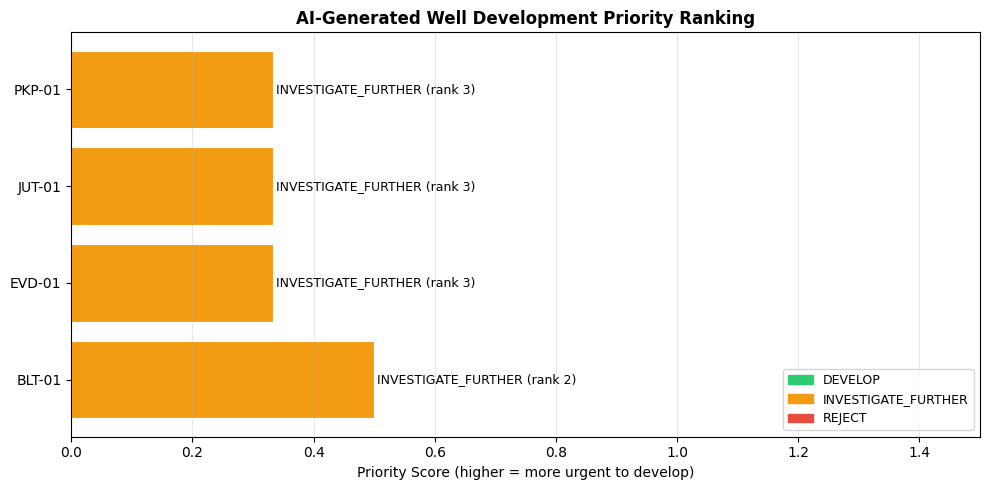

Saved: 08_ai_priority_ranking.png


In [7]:
if reports:
    fig, ax = plt.subplots(figsize=(10, 5))

    well_names = [r.well_id for r in reports]
    priorities = [r.assessment.get("recommendation", {}).get("priority_rank", 99) for r in reports]
    actions    = [r.recommendation for r in reports]

    action_colors = {"DEVELOP": "#2ecc71", "INVESTIGATE_FURTHER": "#f39c12", "REJECT": "#e74c3c"}
    bar_colors = [action_colors.get(a, "#95a5a6") for a in actions]

    bars = ax.barh(well_names, [1/max(p,1) for p in priorities],
                   color=bar_colors, edgecolor="white", lw=0.8)

    for bar, action, priority in zip(bars, actions, priorities):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f"{action} (rank {priority})", va="center", fontsize=9)

    ax.set_xlabel("Priority Score (higher = more urgent to develop)", fontsize=10)
    ax.set_title("AI-Generated Well Development Priority Ranking", fontsize=12, fontweight="bold")
    patches = [mpatches.Patch(color=v, label=k) for k, v in action_colors.items()]
    ax.legend(handles=patches, fontsize=9, loc="lower right")
    ax.set_xlim(0, 1.5)
    ax.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "08_ai_priority_ranking.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: 08_ai_priority_ranking.png")
else:
    print("No reports to plot.")


## 7. Demonstrate the full one-call automation

This is the key bonus deliverable — a single function call that takes a well name and returns a complete structured report.

In [8]:
print("""
BONUS CHALLENGE DEMONSTRATION
==============================
The GeothermalAIAssistant class provides a single automation entry point:

    from src.ai_workflow.assistant import GeothermalAIAssistant, build_request_from_dataframes

    # Step 1: Build request from your processed DataFrames
    request = build_request_from_dataframes(
        well_id     = "BLT-01",
        unified_df  = unified,       # permeability_profiles.csv
        scores_df   = scores,        # feasibility_scores.csv
        thermogis_df = thermo_df,    # ThermoGIS Data.xlsx
    )

    # Step 2: One call → full structured assessment
    assistant = GeothermalAIAssistant()
    report    = assistant.assess_well(request)

    # Step 3: Output options
    print(report.recommendation)       # "DEVELOP" / "INVESTIGATE_FURTHER" / "REJECT"
    print(report.to_markdown())        # Full readable report
    report.save("BLT-01_report.md")   # Save to disk

What the AI returns (structured JSON):
  ├── data_quality        rating, completeness %, key issues, imputation needed
  ├── petrophysical       lithology, porosity, net reservoir quality
  ├── reservoir_potential perm assessment, flow capacity, heat target met Y/N
  ├── risk_register       up to 5 risks with severity + mitigation
  └── recommendation      DEVELOP/INVESTIGATE/REJECT + rationale + next steps

This satisfies the bonus challenge requirement: a genuine automated system
that takes raw well data as input and outputs a decision-ready assessment.
""")



BONUS CHALLENGE DEMONSTRATION
The GeothermalAIAssistant class provides a single automation entry point:

    from src.ai_workflow.assistant import GeothermalAIAssistant, build_request_from_dataframes

    # Step 1: Build request from your processed DataFrames
    request = build_request_from_dataframes(
        well_id     = "BLT-01",
        unified_df  = unified,       # permeability_profiles.csv
        scores_df   = scores,        # feasibility_scores.csv
        thermogis_df = thermo_df,    # ThermoGIS Data.xlsx
    )

    # Step 2: One call → full structured assessment
    assistant = GeothermalAIAssistant()
    report    = assistant.assess_well(request)

    # Step 3: Output options
    print(report.recommendation)       # "DEVELOP" / "INVESTIGATE_FURTHER" / "REJECT"
    print(report.to_markdown())        # Full readable report
    report.save("BLT-01_report.md")   # Save to disk

What the AI returns (structured JSON):
  ├── data_quality        rating, completeness %, key issue

## 8. Workflow summary — what was automated

In [9]:
print("""
FULL AI WORKFLOW AUTOMATION SUMMARY
=====================================

STEP 1 — Data Ingestion (las_loader.py)
  Input:  4 raw LAS files (11.3 MB of well log data)
  Output: Clean pandas DataFrames, nulls removed, consistent schema

STEP 2 — Depth Correction (depth_converter.py)
  Input:  JUT-01 measured depth + survey table
  Output: True Vertical Depth column (required for all depth analysis)

STEP 3 — Formation Tagging (schema_builder.py)
  Input:  All 4 wells + Lithostratigraphic Data.xlsx
  Output: Rotliegend interval flagged per well

STEP 4 — ML Imputation (imputer.py)
  Input:  Sparse well logs
  Output: P10/P50/P90 imputed values for NPHI, DT, DTS, RS

STEP 5 — Permeability Prediction (permeability.py)
  Input:  Imputed logs + ThermoGIS calibration
  Output: Depth-resolved permeability + SHAP explanations

STEP 6 — Feasibility Scoring (feasibility.py)
  Input:  All reservoir parameters per well
  Output: 0–100 score + heat output estimate per scenario

STEP 7 — Economic Integration (scenario_runner.py)
  Input:  Reservoir + surface + economic parameters
  Output: LCoE, NPV, payback period per scenario

STEP 8 — AI Assessment (assistant.py)  ← BONUS CHALLENGE
  Input:  All processed well data (automated via build_request_from_dataframes)
  Output: Structured JSON report with recommendation

Total automated pipeline: raw LAS → investment decision
""")



FULL AI WORKFLOW AUTOMATION SUMMARY

STEP 1 — Data Ingestion (las_loader.py)
  Input:  4 raw LAS files (11.3 MB of well log data)
  Output: Clean pandas DataFrames, nulls removed, consistent schema

STEP 2 — Depth Correction (depth_converter.py)
  Input:  JUT-01 measured depth + survey table
  Output: True Vertical Depth column (required for all depth analysis)

STEP 3 — Formation Tagging (schema_builder.py)
  Input:  All 4 wells + Lithostratigraphic Data.xlsx
  Output: Rotliegend interval flagged per well

STEP 4 — ML Imputation (imputer.py)
  Input:  Sparse well logs
  Output: P10/P50/P90 imputed values for NPHI, DT, DTS, RS

STEP 5 — Permeability Prediction (permeability.py)
  Input:  Imputed logs + ThermoGIS calibration
  Output: Depth-resolved permeability + SHAP explanations

STEP 6 — Feasibility Scoring (feasibility.py)
  Input:  All reservoir parameters per well
  Output: 0–100 score + heat output estimate per scenario

STEP 7 — Economic Integration (scenario_runner.py)
  Inpu